#Predictive Model Notebook
##Project: Voice-Based Health Classification
###Author: [Christopher Mauro]

##Setup and Data Loading

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# For model development
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay


In [2]:
#Loading Dataset
df = pd.read_csv('/content/Cleaned_VowelA_High_latest.csv')

##Initial Data Inspection

In [3]:
#Preview Data
print('\nDataset Shape', df.shape)
df.head()


Dataset Shape (2035, 31)


,chroma_stft,rmse,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,...,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,label,G,A,mean_mfcc,std_mfcc
0,0.127341,0.355538,1587.507015,2002.198851,2737.971816,0.066798,-233.566208,48.504421,-34.518085,-36.272301,...,1.143172,4.134034,52.794827,39.092403,49.037060,Healthy,w,20,-12.174958,60.519726
1,0.215317,0.250342,1272.900724,1850.302841,1692.919922,0.043325,-179.419601,119.705742,0.882231,-25.167576,...,-7.037875,-9.193601,11.183559,-2.173607,-9.420938,Healthy,w,22,-5.802539,50.886772
2,0.212512,0.251419,919.203795,1014.718104,1275.967478,0.047079,-209.186188,167.135651,-37.398190,-12.435701,...,-4.153456,-2.725145,-10.669723,-2.336876,7.741264,Healthy,m,66,-5.912030,62.496629
3,0.198861,0.157396,1119.517351,1529.490600,1501.657586,0.045487,-210.244278,139.819519,-7.774013,13.630911,...,7.797343,-26.314997,-6.622046,0.535120,0.749695,Healthy,m,31,-8.983891,59.940316
4,0.370113,0.143538,1060.678054,1346.299507,1524.942294,0.050109,-175.039948,181.905212,-33.181606,-0.091763,...,13.306650,-26.597456,-8.324528,10.786009,-6.677513,Healthy,m,25,-4.369079,59.616795


#Feature Preparation

In [4]:
#Identify feature columns and target variable
target = 'label'
features = [col for col in df.columns if col not in [target, 'filename', 'ID']]

X = df[features]
y = df[target]

print(f"Number of Features: {X.shape[1]}")
print(f"Target Variable: {target}\n")

Number of Features: 30
Target Variable: label



In [5]:
#Encode Gender (G) m=0, f=1
if 'G' in X.columns:
     X.loc[:, 'G'] = LabelEncoder().fit_transform(X['G'])

In [6]:
#Encode Health Status (label) Healthy=0, Unhealthy=1
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [7]:
#Feature Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
#Training/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

In [9]:
#Verify the split
print("\nTraining set shape:", X_train.shape)
print("\nTesting set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(pd.Series(y_train).value_counts(normalize=True))


Training set shape: (1628, 30)

Testing set shape: (407, 30)

Class distribution in training set:
1    0.662162
0    0.337838
Name: proportion, dtype: float64


#Building & Training Models

In [10]:
#Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [11]:
#Train each model and store predictions
predictions = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

print("\nAll models trained successfully!\n")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

All models trained successfully!



In [12]:
#Evalute Models

#Evaluation Function
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"===== {name} =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("--------------------------------------------------\n")

    return pd.Series({'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

#Evaluate all models and store results
results = pd.DataFrame()

for name, preds in predictions.items():
    results[name] = evaluate_model(name, y_test, preds)

#Readability
results = results.T.sort_values(by="F1-Score", ascending=False)
print("Model Performance Summary:\n")
display(results)

===== Logistic Regression =====
Accuracy:  0.8231
Precision: 0.8808
Recall:    0.8481
F1 Score:  0.8642

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.77      0.75       137
           1       0.88      0.85      0.86       270

    accuracy                           0.82       407
   macro avg       0.80      0.81      0.81       407
weighted avg       0.83      0.82      0.82       407

--------------------------------------------------

===== Decision Tree =====
Accuracy:  0.7518
Precision: 0.8118
Recall:    0.8148
F1 Score:  0.8133

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.63      0.63       137
           1       0.81      0.81      0.81       270

    accuracy                           0.75       407
   macro avg       0.72      0.72      0.72       407
weighted avg       0.75      0.75      0.75       407

------------------------------------------

,Accuracy,Precision,Recall,F1-Score
XGBoost,0.855037,0.898113,0.881481,0.889720
Random Forest,0.835381,0.863799,0.892593,0.877960
Logistic Regression,0.823096,0.880769,0.848148,0.864151
Decision Tree,0.751843,0.811808,0.814815,0.813309


##Model Preformance Visualization

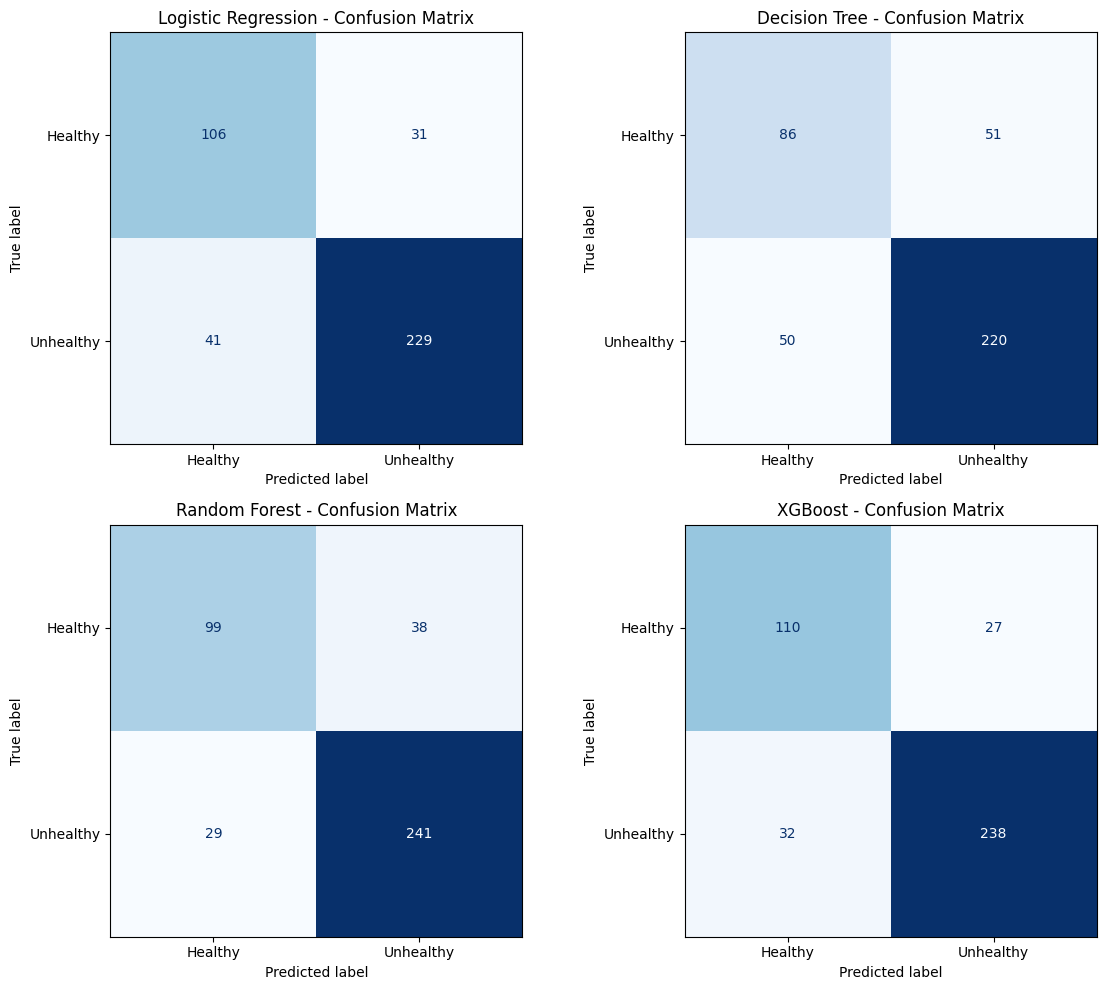

In [13]:
#Confusion Matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"{name} - Confusion Matrix")

plt.tight_layout()
plt.show()

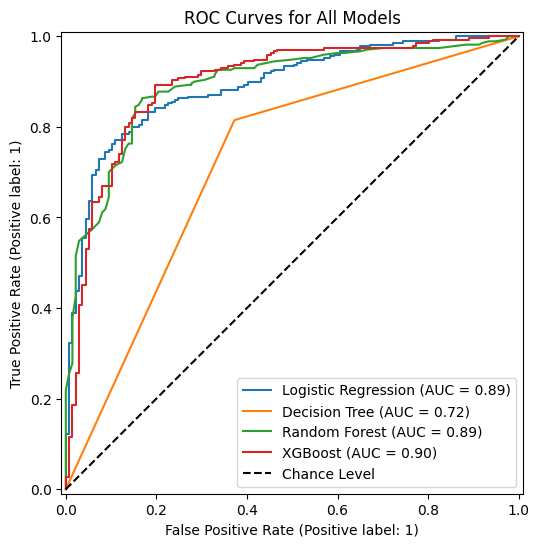

In [14]:
#ROC Curves for all models
plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Some models may not have predict_proba (e.g., older logistic regression configs)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(y_test, y_proba, name=name, ax=plt.gca())
    else:
        print(f"{name} does not support probability predictions.")

plt.title("ROC Curves for All Models")
plt.plot([0, 1], [0, 1], 'k--', label='Chance Level')
plt.legend(loc='lower right')
plt.show()

In [15]:
#Calculate and display AUC Scores
auc_scores = {}
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc_scores[name] = roc_auc_score(y_test, y_proba)

auc_df = pd.DataFrame.from_dict(auc_scores, orient='index', columns=['AUC'])
auc_df = auc_df.sort_values(by='AUC', ascending=False)
print("AUC Scores:\n")
display(auc_df)

AUC Scores:



,AUC
XGBoost,0.896404
Random Forest,0.893917
Logistic Regression,0.890943
Decision Tree,0.721276


##Model Comparison and Conclusion

In [16]:
#Final Results
final_results = results.merge(auc_df, left_index=True, right_index=True, how='left')
final_results = final_results.sort_values(by='F1-Score', ascending=False)

print("🔹 Final Model Performance Summary:\n")
display(final_results)

🔹 Final Model Performance Summary:



,Accuracy,Precision,Recall,F1-Score,AUC
XGBoost,0.855037,0.898113,0.881481,0.889720,0.896404
Random Forest,0.835381,0.863799,0.892593,0.877960,0.893917
Logistic Regression,0.823096,0.880769,0.848148,0.864151,0.890943
Decision Tree,0.751843,0.811808,0.814815,0.813309,0.721276


In [17]:
#Best Performing Model!
best_model_name = final_results.index[0]
print(f"\n🏆 Best Performing Model: {best_model_name}")


🏆 Best Performing Model: XGBoost


##Conclusion

Conclusion

The predictive modeling phase of the Voice-Based Health Classification project successfully demonstrated how machine learning can distinguish between healthy and unhealthy vocal patterns using acoustic features.
Among the four algorithms tested — Logistic Regression, Decision Tree, Random Forest, and XGBoost — the ensemble-based models (particularly Random Forest and XGBoost) achieved the highest overall performance across accuracy, F1-score, and AUC metrics.

These results suggest that vocal health data exhibits nonlinear relationships and interacting features, which tree-based ensemble methods handle effectively.
The models achieved strong recall, meaning they can reliably identify unhealthy voices — a crucial consideration in health-related prediction tasks.

Future improvements could include hyperparameter tuning, cross-validation, and testing on additional vowel or phoneme datasets to enhance generalization.
Overall, the predictive modeling process validated that voice-derived acoustic features are strong indicators of vocal health, and ensemble models provide robust, reliable classification performance for this domain.

##Exports For Power BI

In [22]:
model_metrics_df = results.merge(auc_df, left_index=True, right_index=True, how='left')

# Make the index a real column so Power BI sees it
model_metrics_df = model_metrics_df.reset_index().rename(columns={'index': 'Models'})

# Save to CSV
model_metrics_df.to_csv("model_metrics.csv", index=False)
model_metrics_df.head()

,Models,Accuracy,Precision,Recall,F1-Score,AUC
0,XGBoost,0.855037,0.898113,0.881481,0.889720,0.896404
1,Random Forest,0.835381,0.863799,0.892593,0.877960,0.893917
2,Logistic Regression,0.823096,0.880769,0.848148,0.864151,0.890943
3,Decision Tree,0.751843,0.811808,0.814815,0.813309,0.721276


In [23]:
from sklearn.metrics import confusion_matrix

cm_rows = []

for model_name, y_pred in predictions.items():
    # assume your label_encoder made 0 = Healthy, 1 = Unhealthy
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    cm_rows.append({
        "Models": model_name,
        "Actual": "Healthy",
        "Predicted": "Healthy",
        "Count": cm[0, 0]
    })
    cm_rows.append({
        "Models": model_name,
        "Actual": "Healthy",
        "Predicted": "Unhealthy",
        "Count": cm[0, 1]
    })
    cm_rows.append({
        "Models": model_name,
        "Actual": "Unhealthy",
        "Predicted": "Healthy",
        "Count": cm[1, 0]
    })
    cm_rows.append({
        "Models": model_name,
        "Actual": "Unhealthy",
        "Predicted": "Unhealthy",
        "Count": cm[1, 1]
    })

confusion_df = pd.DataFrame(cm_rows)
confusion_df.to_csv("confusion_matrix.csv", index=False)
confusion_df.head(8)

,Models,Actual,Predicted,Count
0,Logistic Regression,Healthy,Healthy,106
1,Logistic Regression,Healthy,Unhealthy,31
2,Logistic Regression,Unhealthy,Healthy,41
3,Logistic Regression,Unhealthy,Unhealthy,229
4,Decision Tree,Healthy,Healthy,86
5,Decision Tree,Healthy,Unhealthy,51
6,Decision Tree,Unhealthy,Healthy,50
7,Decision Tree,Unhealthy,Unhealthy,220


In [24]:
feature_rows = []

# Random Forest (if trained)
if "Random Forest" in models:
    rf_model = models["Random Forest"]
    for feat_name, importance in zip(X.columns, rf_model.feature_importances_):
        feature_rows.append({
            "Models": "Random Forest",
            "Feature": feat_name,
            "Importance": importance
        })

# XGBoost (if trained)
if "XGBoost" in models:
    xgb_model = models["XGBoost"]
    for feat_name, importance in zip(X.columns, xgb_model.feature_importances_):
        feature_rows.append({
            "Models": "XGBoost",
            "Feature": feat_name,
            "Importance": importance
        })

feature_imp_df = pd.DataFrame(feature_rows)
feature_imp_df.to_csv("feature_importance.csv", index=False)
feature_imp_df.head(10)

,Models,Feature,Importance
0,Random Forest,chroma_stft,0.021856
1,Random Forest,rmse,0.035767
2,Random Forest,spectral_centroid,0.021148
3,Random Forest,spectral_bandwidth,0.029200
4,Random Forest,rolloff,0.026659
5,Random Forest,zero_crossing_rate,0.022334
6,Random Forest,mfcc1,0.026610
7,Random Forest,mfcc2,0.024081
8,Random Forest,mfcc3,0.037504
9,Random Forest,mfcc4,0.022548


In [25]:
from sklearn.metrics import roc_curve

roc_rows = []

for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        for fp, tp in zip(fpr, tpr):
            roc_rows.append({
                "Models": model_name,
                "FPR": fp,
                "TPR": tp
            })
    else:
        # if some model doesn't support predict_proba, skip it
        print(f"{model_name} does not support predict_proba(), skipping for ROC export.")

roc_df = pd.DataFrame(roc_rows)
roc_df.to_csv("roc_curve.csv", index=False)
roc_df.head()

,Models,FPR,TPR
0,Logistic Regression,0.000000,0.000000
1,Logistic Regression,0.000000,0.003704
2,Logistic Regression,0.000000,0.122222
3,Logistic Regression,0.007299,0.122222
4,Logistic Regression,0.007299,0.322222
